# Temp Tsujii Figure: Diurnal Ratio
Simple species-level comparison of paired night/day metabolic-rate ratios.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Toggle: include filtered=False rows if needed.
use_unfiltered = False

# Locate processed summary from common notebook working directories.
candidate_paths = [
    Path.cwd() / '../data/processed/batch_summary.csv',
    Path.cwd() / 'data/processed/batch_summary.csv',
]

data_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find data/processed/batch_summary.csv')

agg_df = pd.read_csv(data_path)
analysis_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

required_cols = {'trial', 'brick', 'channel', 'environment', 'RMR', 'species'}
missing = required_cols - set(analysis_df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

print(f'Loaded {len(agg_df)} total rows from {data_path}')
print(f'Rows in analysis set: {len(analysis_df)} (use_unfiltered={use_unfiltered})')

Loaded 73 total rows from /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv
Rows in analysis set: 60 (use_unfiltered=False)


In [2]:
# Load shared Figure style + palette (same pattern as Figure 2 notebook).
import importlib.util

style_dir_candidates = [
    Path.cwd() / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

LIGHT_BLUE = palette['light_blue']
DARK_BLUE = palette['dark_blue']
LIGHT_ORANGE = palette['light_orange']
DARK_ORANGE = palette['dark_orange']

print(f'Shared style loaded from: {style_path}')

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle


In [3]:
# Build paired-trial table (Figure 1 pairs + tsujii pair), then compute ratio = night/day.
pair_trials = [
    ('trial4', 'trial4.5'),
    ('trial5', 'trial5.5'),
    ('trial6', 'trial6.5'),
    ('trial7', 'trial7.5'),
    ('trialtsu1', 'trialtsu1.5'),
]

paired_rows = []
for t_a, t_b in pair_trials:
    pair_df = analysis_df[analysis_df['trial'].isin([t_a, t_b])].copy()
    if pair_df.empty:
        continue

    for (brick, channel), grp in pair_df.groupby(['brick', 'channel']):
        if len(grp) != 2:
            continue

        envs = set(grp['environment'].astype(str))
        if envs != {'day', 'night'}:
            continue

        night_row = grp[grp['environment'] == 'night'].iloc[0]
        day_row = grp[grp['environment'] == 'day'].iloc[0]

        species_candidates = [night_row.get('species'), day_row.get('species')]
        species = next((s for s in species_candidates if pd.notna(s) and str(s).strip() != ''), 'unknown')

        day_rmr = float(day_row['RMR'])
        night_rmr = float(night_row['RMR'])
        if day_rmr <= 0:
            # Ratios are undefined/non-informative if day <= 0; skip those pairs.
            continue

        paired_rows.append({
            'pair': f'{t_a}_vs_{t_b}',
            'trial_night': t_a,
            'trial_day': t_b,
            'brick': brick,
            'channel': channel,
            'species': species,
            'night_RMR': night_rmr,
            'day_RMR': day_rmr,
            'night_day_ratio': night_rmr / day_rmr,
        })

ratio_df = pd.DataFrame(paired_rows)
print(f'Paired rows retained for ratio: {len(ratio_df)}')
if not ratio_df.empty:
    print('Counts by species:')
    print(ratio_df['species'].value_counts())
display(ratio_df)

Paired rows retained for ratio: 18
Counts by species:
species
Photeros_EGD      17
Vargula_tsujii     1
Name: count, dtype: int64


,pair,trial_night,trial_day,brick,channel,species,night_RMR,day_RMR,night_day_ratio
0,trial5_vs_trial5.5,trial5,trial5.5,box3,Ch2,Photeros_EGD,2.285837,2.245259,1.018073
1,trial5_vs_trial5.5,trial5,trial5.5,box3,Ch3,Photeros_EGD,0.920854,0.427888,2.152088
2,trial5_vs_trial5.5,trial5,trial5.5,box3,Ch4,Photeros_EGD,0.473624,0.706451,0.670427
3,trial5_vs_trial5.5,trial5,trial5.5,newbox,Ch2,Photeros_EGD,1.871534,0.756193,2.474942
4,trial5_vs_trial5.5,trial5,trial5.5,newbox,Ch3,Photeros_EGD,1.876437,1.199553,1.564280
5,trial5_vs_trial5.5,trial5,trial5.5,newbox,Ch4,Photeros_EGD,2.681803,2.995435,0.895297
6,trial6_vs_trial6.5,trial6,trial6.5,box3,Ch2,Photeros_EGD,1.954137,0.949858,2.057295
7,trial6_vs_trial6.5,trial6,trial6.5,box3,Ch4,Photeros_EGD,2.182509,0.679472,3.212065
8,trial6_vs_trial6.5,trial6,trial6.5,newbox,Ch2,Photeros_EGD,3.222056,1.841349,1.749835
9,trial6_vs_trial6.5,trial6,trial6.5,newbox,Ch3,Photeros_EGD,1.424907,0.920279,1.548341


Data points per species -> Photeros_EGD: n=17, Vargula_tsujii: n=1


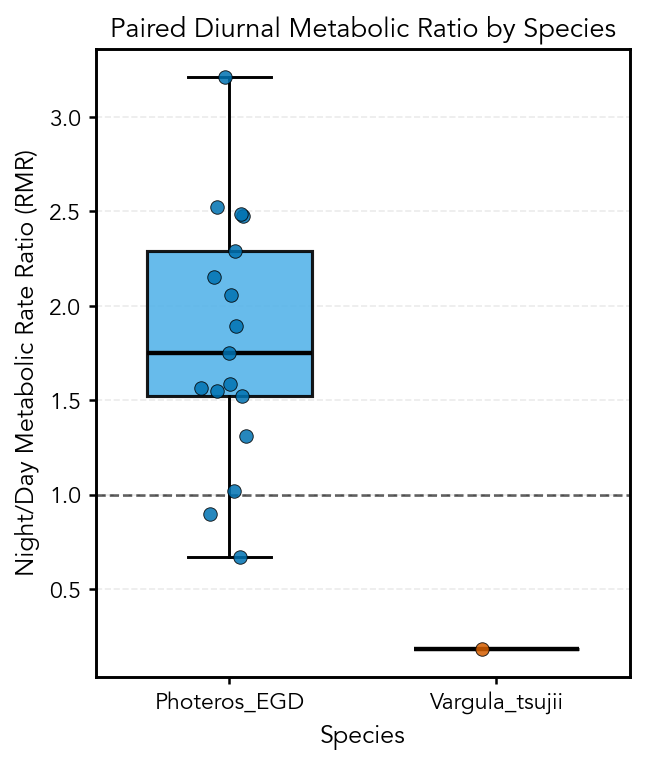

In [4]:
# Box-and-whisker + points: y-axis is night/day metabolic-rate ratio, grouped by species.
if ratio_df.empty:
    print('No paired ratio data available to plot.')
else:
    species_order = ['Photeros_EGD', 'Vargula_tsujii']
    available_species = [s for s in species_order if s in set(ratio_df['species'])]
    if not available_species:
        available_species = sorted(ratio_df['species'].dropna().unique())

    data_by_species = [
        ratio_df.loc[ratio_df['species'] == sp, 'night_day_ratio'].dropna().to_numpy()
        for sp in available_species
    ]

    x = np.arange(1, len(available_species) + 1)
    fig, ax = plt.subplots(figsize=(4.4, 5.2))

    box_fill_colors = []
    point_colors = []
    for sp in available_species:
        if sp == 'Photeros_EGD':
            box_fill_colors.append(LIGHT_BLUE)
            point_colors.append(DARK_BLUE)
        elif sp == 'Vargula_tsujii':
            box_fill_colors.append(LIGHT_ORANGE)
            point_colors.append(DARK_ORANGE)
        else:
            box_fill_colors.append('#b0b0b0')
            point_colors.append('#5a5a5a')

    bp = ax.boxplot(
        data_by_species,
        positions=x,
        widths=0.62,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=2.1, color='black'),
        boxprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.4, color='black'),
        capprops=dict(linewidth=1.4, color='black'),
    )

    for patch, face_color in zip(bp['boxes'], box_fill_colors):
        patch.set_facecolor(face_color)
        patch.set_alpha(0.9)

    rng = np.random.default_rng(42)
    for i, (sp, vals) in enumerate(zip(available_species, data_by_species)):
        if len(vals) == 0:
            continue
        jitter = rng.normal(0, 0.055, size=len(vals))
        ax.scatter(
            np.full(len(vals), x[i]) + jitter,
            vals,
            s=42,
            alpha=0.85,
            color=point_colors[i],
            edgecolors='black',
            linewidths=0.45,
            zorder=3,
        )

    ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.7, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(['Photeros_EGD' if s == 'Photeros_EGD' else 'Vargula_tsujii' for s in available_species], rotation=0)
    ax.set_ylabel('Night/Day Metabolic Rate Ratio (RMR)')
    ax.set_xlabel('Species')
    ax.set_title('Paired Diurnal Metabolic Ratio by Species')
    ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)

    counts_txt = ', '.join([f"{sp}: n={int((ratio_df['species'] == sp).sum())}" for sp in available_species])
    print('Data points per species -> ' + counts_txt)

    plt.tight_layout()
    plt.show()

Slopegraph rows plotted: 18


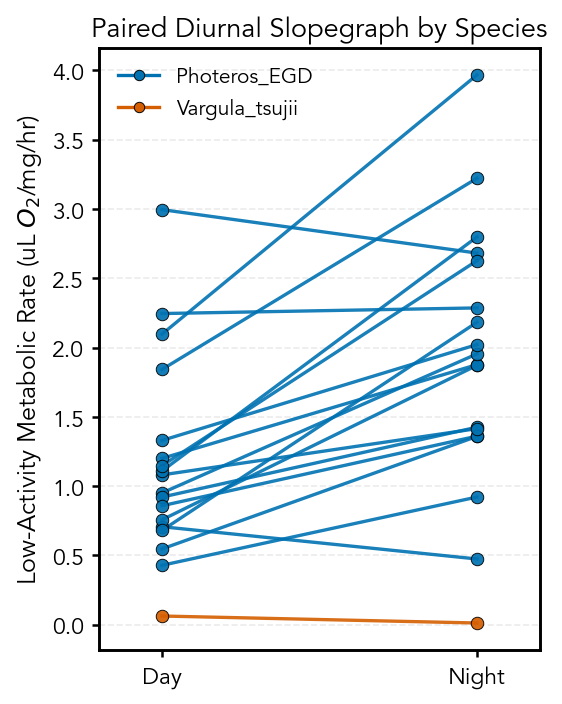

In [5]:
# Slopegraph: absolute day vs night RMR for all paired rows, colored by species.
from matplotlib.lines import Line2D

if ratio_df.empty:
    print('No paired ratio data available to plot.')
else:
    slope_df = ratio_df.copy()
    slope_df = slope_df.sort_values(['species', 'pair', 'brick', 'channel']).reset_index(drop=True)

    # Dynamic height keeps rows legible if more paired points are added.
    fig_slope, ax_slope = plt.subplots(figsize=(3.8, max(4.8, 0.18 * len(slope_df))))
    x_day, x_night = 0, 1

    for _, row in slope_df.iterrows():
        species = str(row['species'])
        color = DARK_BLUE if species == 'Photeros_EGD' else DARK_ORANGE

        ax_slope.plot(
            [x_day, x_night],
            [row['day_RMR'], row['night_RMR']],
            color=color,
            linewidth=1.6,
            alpha=0.9,
            zorder=2,
        )
        ax_slope.scatter(
            [x_day, x_night],
            [row['day_RMR'], row['night_RMR']],
            color=color,
            edgecolors='black',
            linewidths=0.45,
            s=36,
            alpha=0.92,
            zorder=3,
        )

    ax_slope.set_xlim(-0.2, 1.2)
    ax_slope.set_xticks([x_day, x_night])
    ax_slope.set_xticklabels(['Day', 'Night'], fontsize=11, fontweight='bold')
    ax_slope.set_ylabel('Low-Activity Metabolic Rate (uL $O_2$/mg/hr)')
    ax_slope.set_title('Paired Diurnal Slopegraph by Species')
    ax_slope.grid(axis='y', linestyle='--', alpha=0.25)

    legend_handles = [
        Line2D([0], [0], color=DARK_BLUE, marker='o', lw=1.6, markersize=5,
               markeredgecolor='black', markeredgewidth=0.45, label='Photeros_EGD'),
        Line2D([0], [0], color=DARK_ORANGE, marker='o', lw=1.6, markersize=5,
               markeredgecolor='black', markeredgewidth=0.45, label='Vargula_tsujii'),
    ]
    ax_slope.legend(handles=legend_handles, frameon=False, loc='best')

    print(f'Slopegraph rows plotted: {len(slope_df)}')
    plt.tight_layout()
    plt.show()

In [ ]:
# Optional save.
figures_dir = Path.cwd() / '../figures'
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig' in locals():
    out_pdf = (figures_dir / 'TempTsujii_Figure_diurnal.pdf').resolve()
    fig.savefig(out_pdf, bbox_inches='tight')
    print(f'Saved PDF: {out_pdf}')
else:
    print('No figure found. Run plotting cell first.')